In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
print(yf.__version__)


1.0


Descargando: AA1.MX
  -> OK 249 filas
Descargando: ACTINVRB.MX
  -> OK 215 filas
Descargando: FUBO.MX
  -> OK 249 filas
Descargando: GM.MX
  -> OK 249 filas
Descargando: GRUMAB.MX
  -> OK 249 filas
Descargando: NVDA.MX
  -> OK 249 filas
Descarga completa. errores: {}


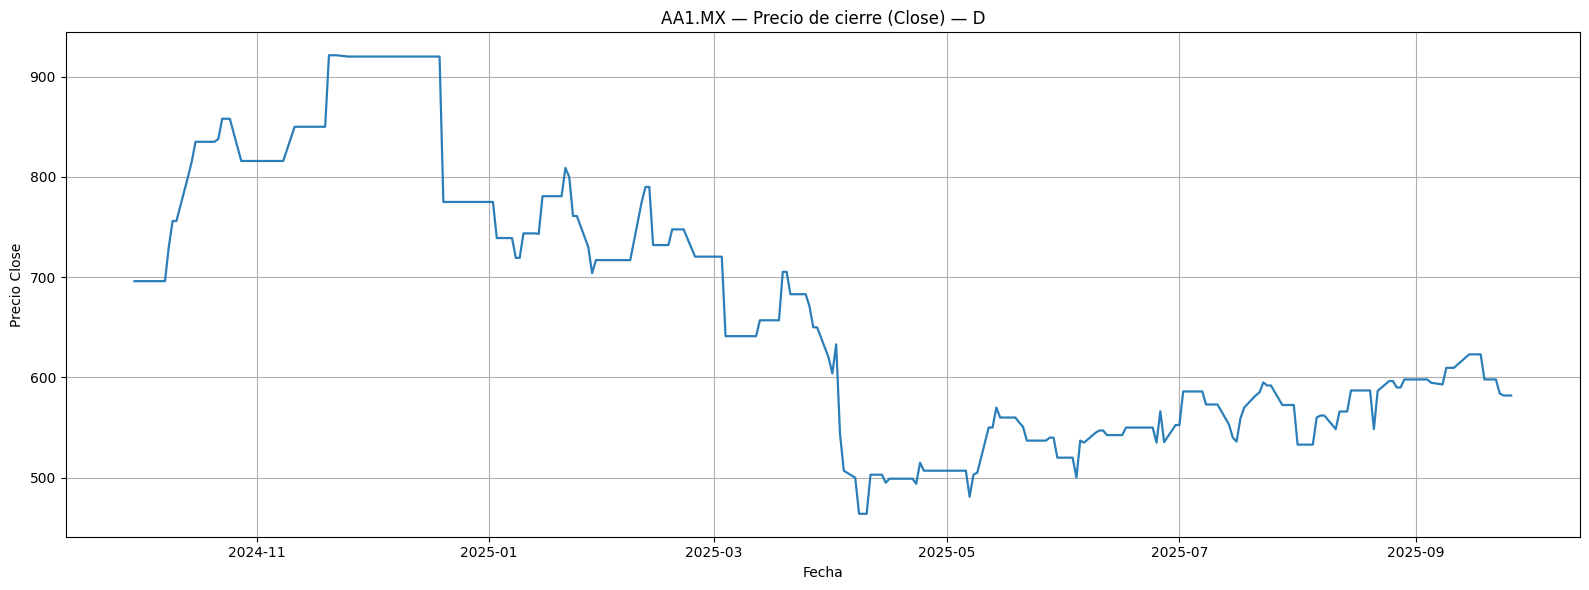

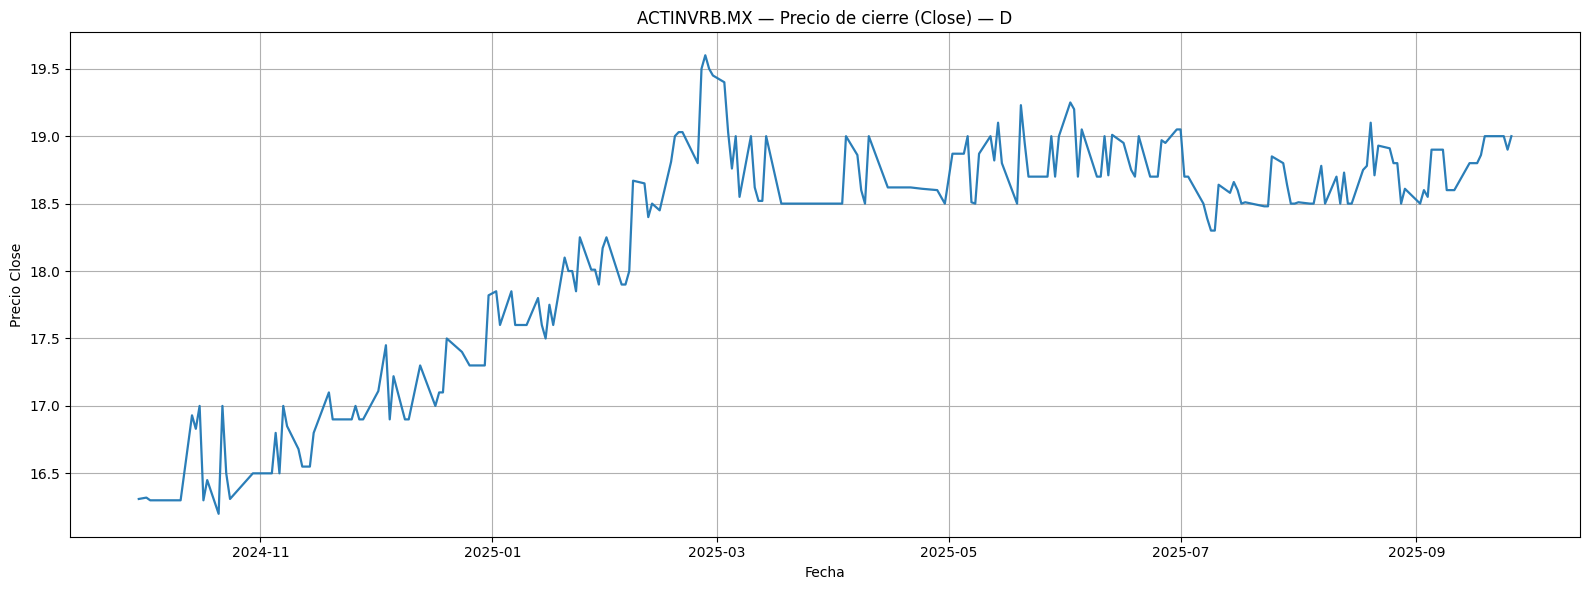

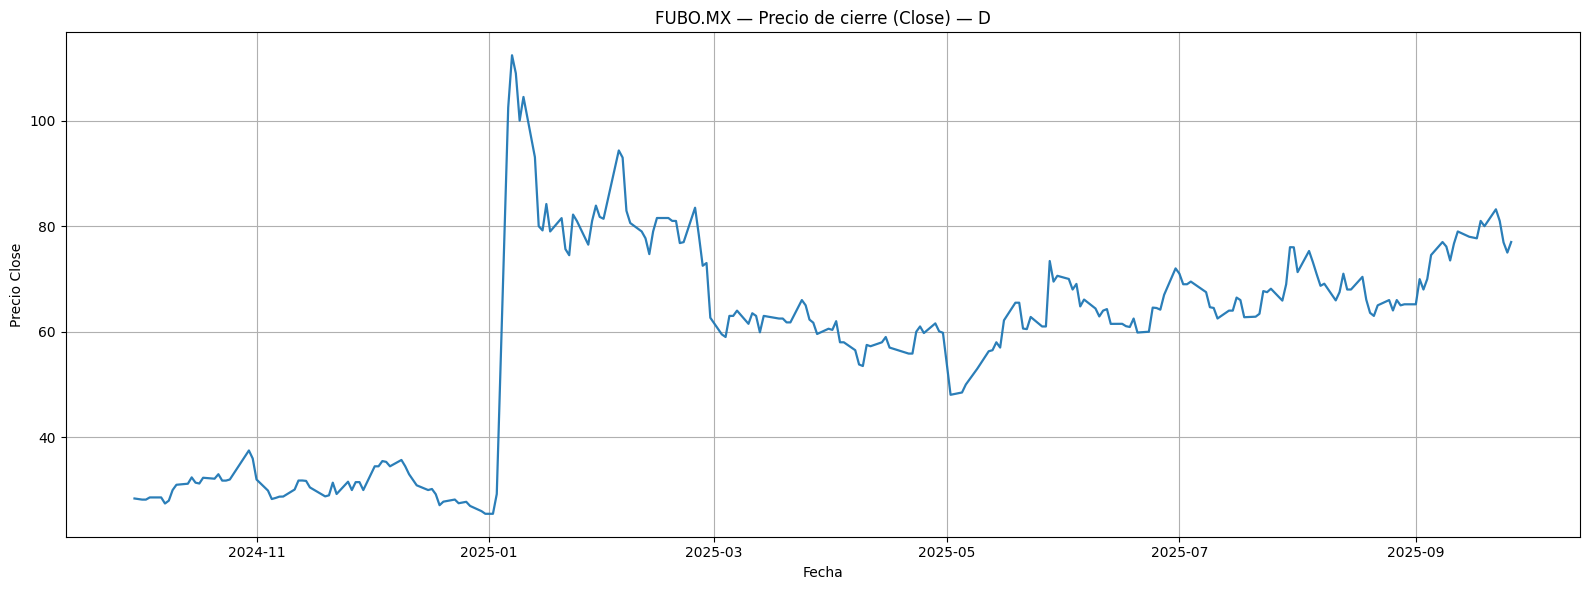

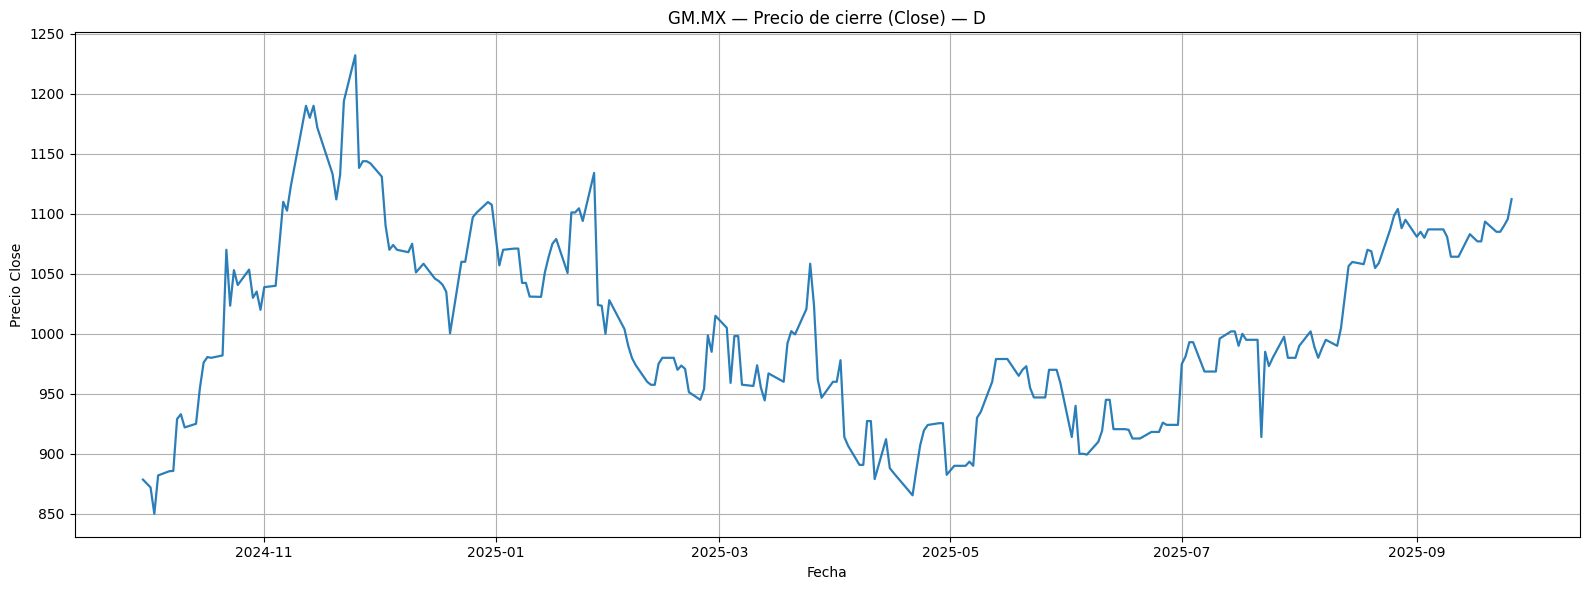

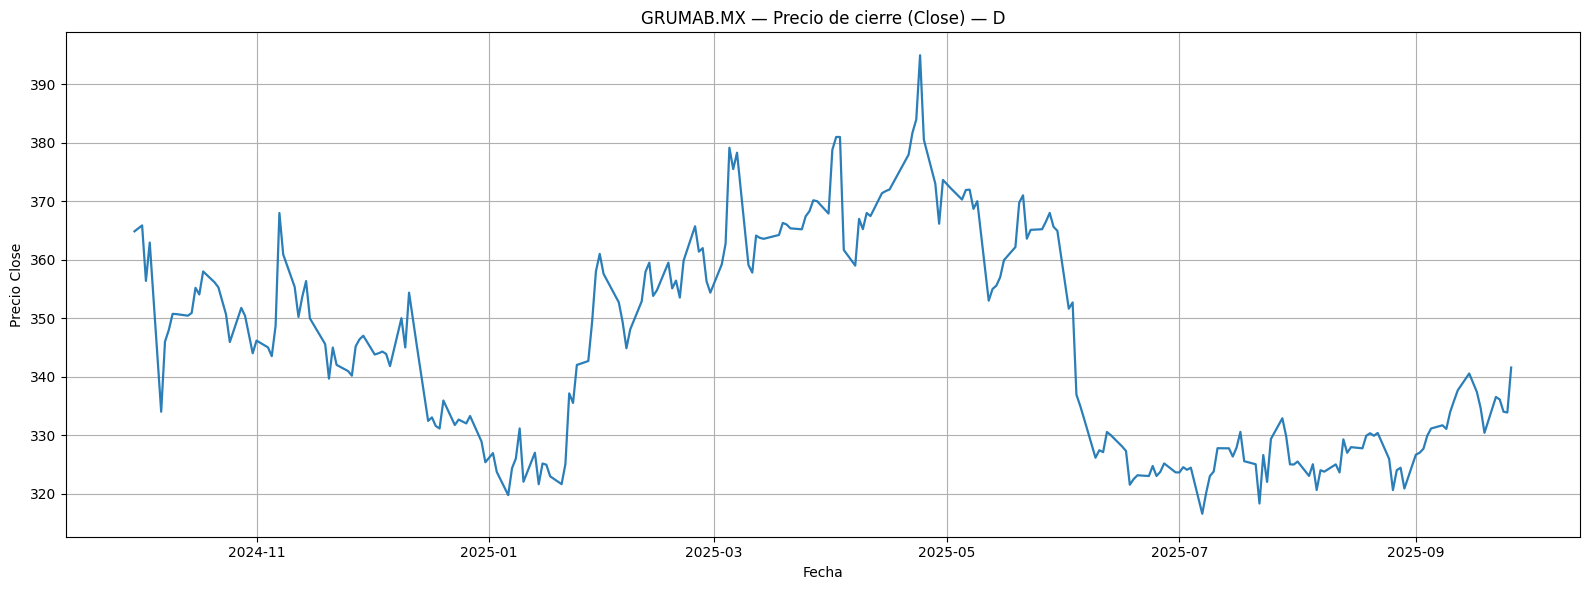

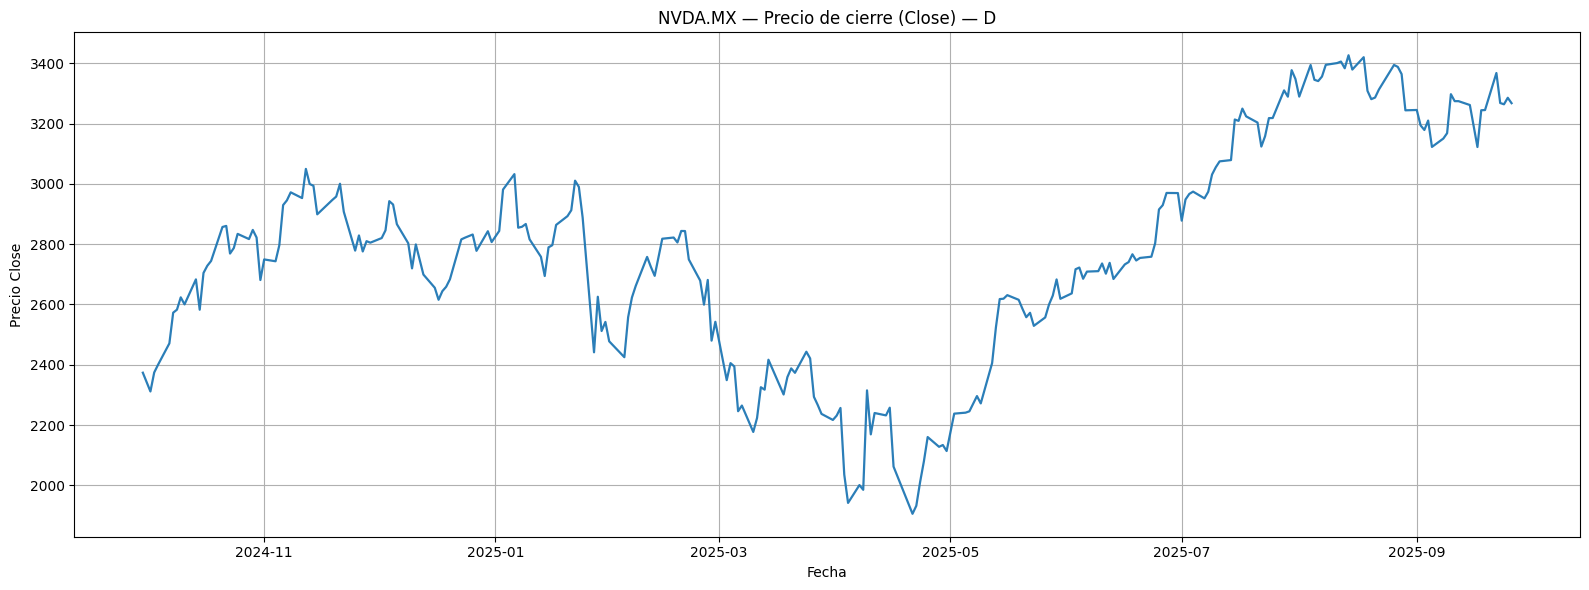

In [2]:
tickers = [
    "AA1.MX",
    "ACTINVRB.MX",
    "FUBO.MX",
    "GM.MX",
    "GRUMAB.MX",
    "NVDA.MX"
]
end_date = "2025-09-28"   # fecha final "YYYY-MM-DD"
years_for_seasonality = 1
period = 'D'   # 'D' diario o 'W' semanal (si quieres semanal cambia más abajo)
output_folder = "plots_step"


# Tamaño del test para la GRAFICA 2 (en días)
test_size_days = 60

# CELDA 2: descargar por ticker (OHLCV) y guardar en dict
from datetime import datetime
end = pd.to_datetime(end_date)
start = end - pd.DateOffset(years=years_for_seasonality)

data_dict = {}
errors = {}

for t in tickers:
    try:
        print("Descargando:", t)
        df = yf.download(t, start=start.strftime("%Y-%m-%d"), end=(end + pd.Timedelta(days=1)).strftime("%Y-%m-%d"), progress=False, auto_adjust=False)
        if df.empty:
            print("  -> Sin datos para", t)
            errors[t] = "no data"
            continue
        # mantener OHLCV
        df = df[['Open','High','Low','Close','Volume']].ffill().dropna()
        # opcional: resample semanal si quieres
        if period == 'W':
            df = df.resample('W-FRI').agg({'Open':'first','High':'max','Low':'min','Close':'last','Volume':'sum'}).dropna()
        data_dict[t] = df
        print(f"  -> OK {df.shape[0]} filas")
    except Exception as e:
        print("  Error", t, e)
        errors[t] = str(e)

print("Descarga completa. errores:", errors)

# CELDA 3 (modificada): SOLO gráficos de precio (Close) por ticker
for t, df in data_dict.items():
    df_plot = df.copy()
    if 'Close' not in df_plot.columns or df_plot['Close'].dropna().shape[0] < 3:
        print(f"{t}: no hay suficiente data de Close ({df_plot.shape[0]} filas). Saltando.")
        continue

    series = df_plot['Close'].copy()

    plt.figure(figsize=(16,6))
    plt.plot(series.index, series.values, linewidth=1.6, alpha=0.95)
    plt.title(f"{t} — Precio de cierre (Close) — {period}")
    plt.xlabel("Fecha")
    plt.ylabel("Precio Close")
    plt.grid(True)
    plt.tight_layout()

    plt.show()


